# Multivariate Household Electric Power Forecasting using Deep Learning and Statistical Models

Device: cpu
Directories created.

Loading dataset...
Data files found:
/content/household_power_data/household_power_consumption.txt

Using: /content/household_power_data/household_power_consumption.txt

Raw dataset shape: (2075259, 9)

Columns:
['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

First five rows:
         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00                4.216                  0.418   234.84   
1  16/12/2006  17:25:00                5.360                  0.436   233.63   
2  16/12/2006  17:26:00                5.374                  0.498   233.29   
3  16/12/2006  17:27:00                5.388                  0.502   233.74   
4  16/12/2006  17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0

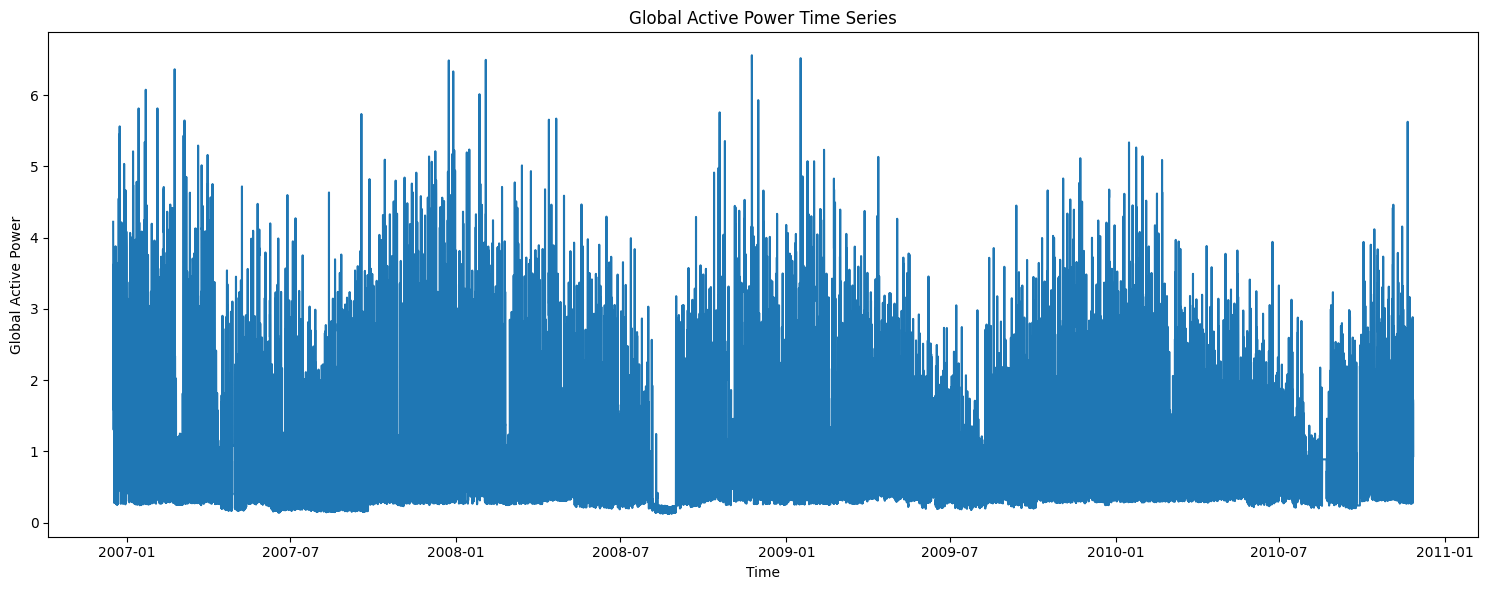

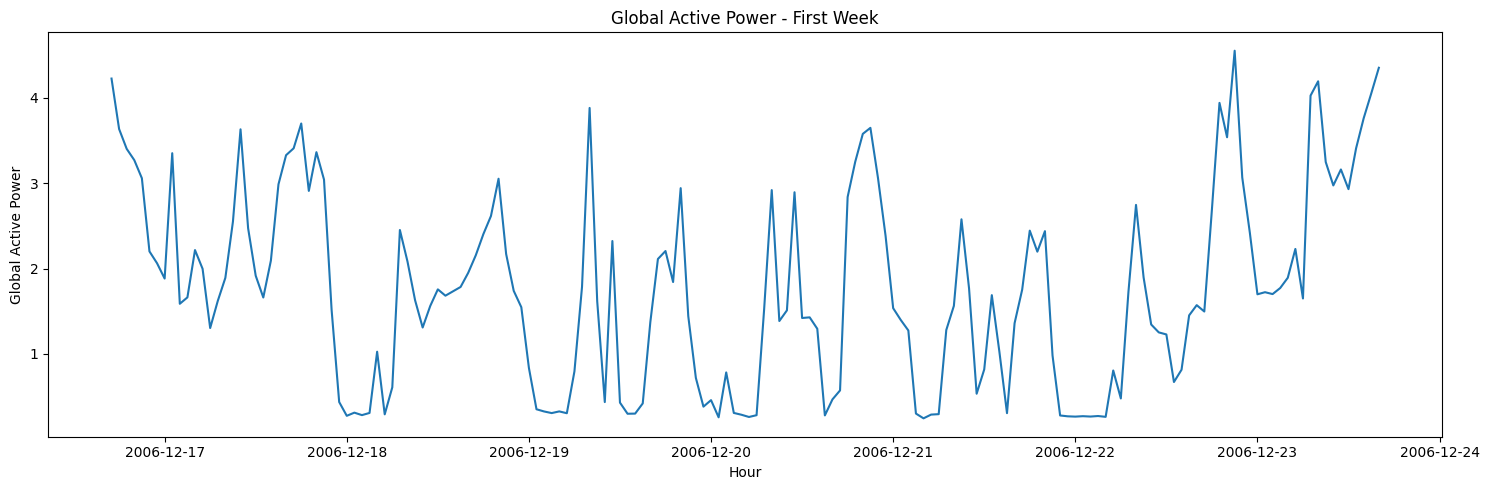

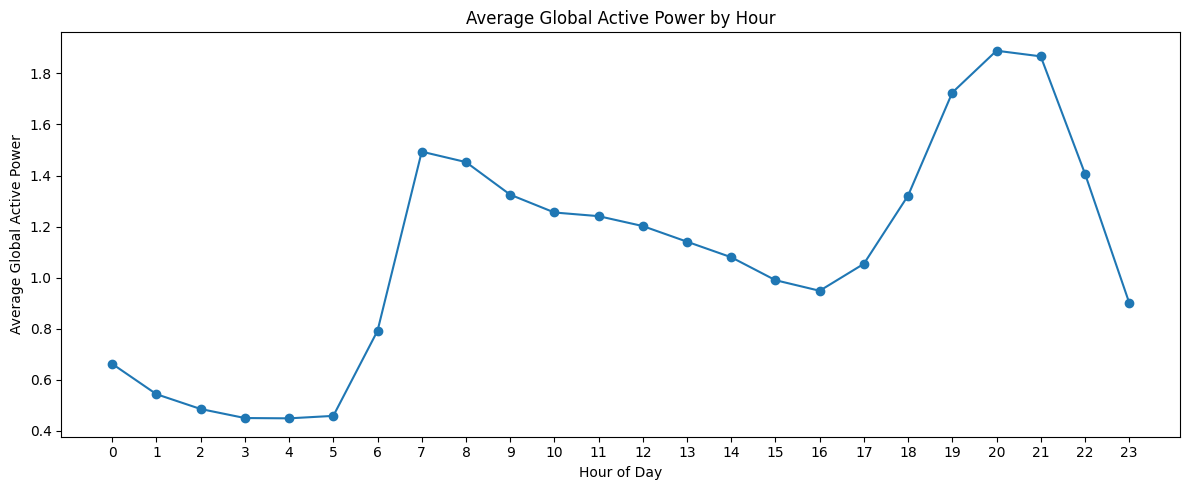

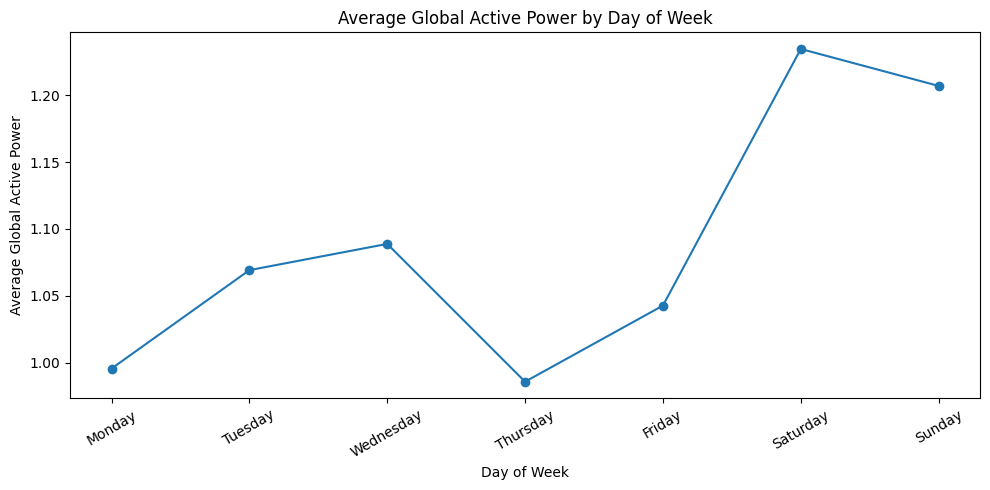

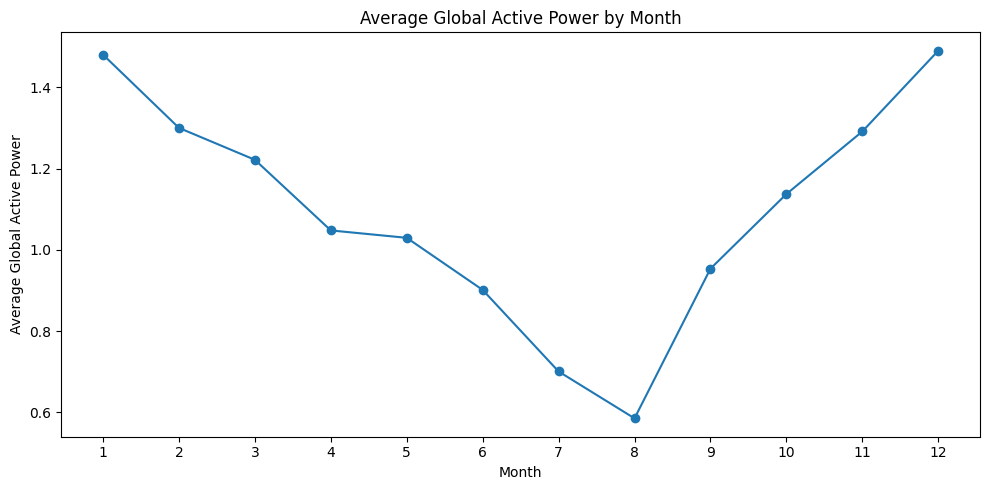

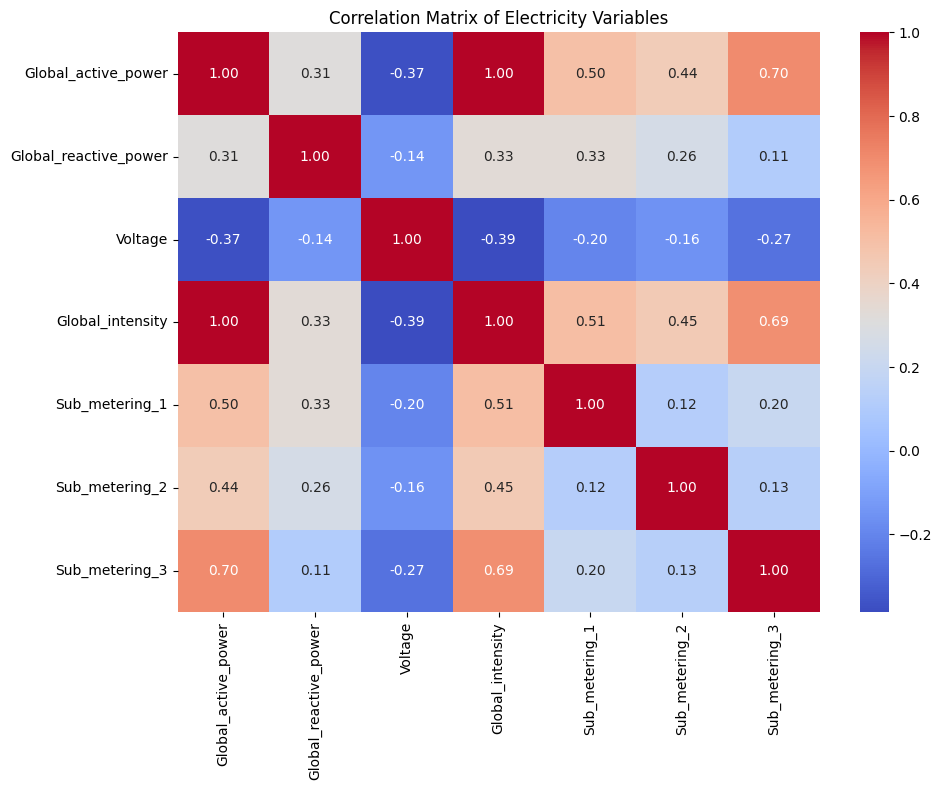


Performing ADF stationarity test...

ADF Statistic: -11.170368
p-value: 0.0
Result: The series is stationary.


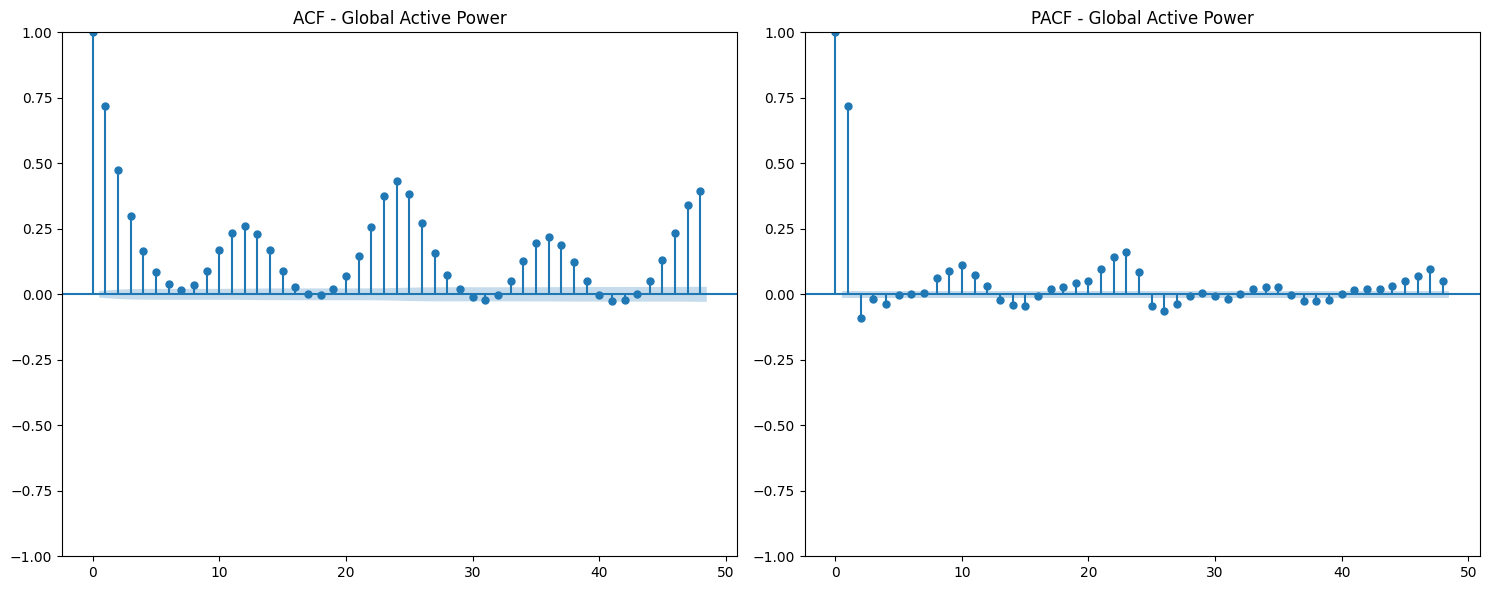


Selecting ARIMA model...
Testing ARIMA: (1, 0, 1)
Testing ARIMA: (1, 0, 2)
Testing ARIMA: (2, 0, 1)
Testing ARIMA: (2, 0, 2)
Testing ARIMA: (2, 1, 2)

ARIMA validation results:
       Order       MAE      RMSE
4  (2, 1, 2)  0.733487  0.898086
1  (1, 0, 2)  0.733972  0.906740
0  (1, 0, 1)  0.733973  0.906743
3  (2, 0, 2)  0.733983  0.906785
2  (2, 0, 1)  0.733984  0.906789

Best ARIMA order: (2, 1, 2)

Training final ARIMA...
ARIMA forecasting completed.

Selecting SARIMA model...
Testing SARIMA: (1, 0, 1) (1, 0, 1, 24)
Testing SARIMA: (1, 0, 1) (1, 0, 2, 24)
Testing SARIMA: (1, 0, 1) (2, 0, 1, 24)


In [ ]:
# ============================================================
# MULTIVARIATE TIME SERIES FORECASTING USING DEEP LEARNING
# ============================================================
#
# Dataset:
# UCI Individual Household Electric Power Consumption
#
# Models:
# 1. ARIMA
# 2. SARIMA
# 3. LSTM
# 4. Temporal Convolutional Network (TCN)
#
# Target:
# Global_active_power
#
# Evaluation:
# MAE, RMSE, MAPE
#
# ============================================================


# ============================================================
# 0. INSTALL / IMPORT LIBRARIES
# ============================================================

import os
import zipfile
import glob
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


# ============================================================
# 2. DIRECTORY SETUP
# ============================================================

directories = [
    "plots",
    "models",
    "results",
    "forecasts"
]

for directory in directories:
    os.makedirs(directory, exist_ok=True)

print("Directories created.")


# ============================================================
# 3. LOAD DATASET
# ============================================================

print("\nLoading dataset...")

file_path = "/content/individual+household+electric+power+consumption.zip"

# ------------------------------------------------------------
# Extract ZIP file
# ------------------------------------------------------------

extract_path = "/content/household_power_data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(file_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Find CSV/TXT files
data_files = glob.glob(
    os.path.join(extract_path, "**", "*"),
    recursive=True
)

data_files = [
    f for f in data_files
    if f.lower().endswith((".txt", ".csv"))
]

print("Data files found:")
for f in data_files:
    print(f)

if len(data_files) == 0:
    raise FileNotFoundError(
        "No CSV/TXT dataset found inside the ZIP file."
    )

data_file = data_files[0]

print("\nUsing:", data_file)


# ============================================================
# 4. READ RAW DATA
# ============================================================

df = pd.read_csv(
    data_file,
    sep=";",
    na_values=["?"],
    low_memory=False
)

print("\nRaw dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst five rows:")
print(df.head())


# ============================================================
# 5. DATETIME PROCESSING
# ============================================================

print("\nProcessing datetime...")

df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True,
    errors="coerce"
)

df.drop(
    columns=["Date", "Time"],
    inplace=True
)

df.set_index("Datetime", inplace=True)

df.sort_index(inplace=True)


# ============================================================
# 6. CONVERT FEATURES TO NUMERIC
# ============================================================

df = df.apply(pd.to_numeric, errors="coerce")

print("\nMissing values before preprocessing:")
print(df.isnull().sum())


# ============================================================
# 7. HOURLY AGGREGATION
# ============================================================

print("\nAggregating data to hourly frequency...")

df_hourly = df.resample("h").mean()

print("Hourly dataset shape:", df_hourly.shape)


# ============================================================
# 8. HANDLE MISSING VALUES
# ============================================================
#
# We use forward filling after hourly aggregation.
# This avoids using future observations to fill earlier
# observations.
# ============================================================

df_hourly = df_hourly.ffill()

# Remaining missing values at the very beginning
# are filled using training-independent column medians.
#
# Since these are only initial observations, this is used
# only as a final safeguard.

df_hourly = df_hourly.bfill()

df_hourly.dropna(inplace=True)

print("\nMissing values after preprocessing:")
print(df_hourly.isnull().sum())


# ============================================================
# 9. DEFINE TARGET
# ============================================================

target_col = "Global_active_power"

print("\nTarget variable:", target_col)


# ============================================================
# 10. SAVE PROCESSED DATASET
# ============================================================

df_hourly.to_csv(
    "results/processed_hourly_dataset.csv"
)

print("\nProcessed dataset saved.")


# ============================================================
# 11. CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT
# ============================================================

n = len(df_hourly)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df_hourly.iloc[:train_end].copy()

val_df = df_hourly.iloc[
    train_end:val_end
].copy()

test_df = df_hourly.iloc[
    val_end:
].copy()

print("\nDataset split:")
print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Testing:", test_df.shape)

print("\nTraining period:")
print(train_df.index.min(), "to", train_df.index.max())

print("\nValidation period:")
print(val_df.index.min(), "to", val_df.index.max())

print("\nTesting period:")
print(test_df.index.min(), "to", test_df.index.max())


# ============================================================
# 12. EXPLORATORY DATA ANALYSIS
# ============================================================

print("\nPerforming EDA...")


# ------------------------------------------------------------
# Descriptive statistics
# ------------------------------------------------------------

desc_stats = df_hourly.describe()

desc_stats.to_csv(
    "results/descriptive_statistics.csv"
)


# ------------------------------------------------------------
# Complete time series
# ------------------------------------------------------------

plt.figure(figsize=(15, 6))

plt.plot(
    df_hourly.index,
    df_hourly[target_col]
)

plt.title(
    "Global Active Power Time Series"
)

plt.xlabel("Time")
plt.ylabel("Global Active Power")

plt.tight_layout()

plt.savefig(
    "plots/complete_time_series.png",
    dpi=300
)

plt.show()
plt.close()


# ------------------------------------------------------------
# First week
# ------------------------------------------------------------

plt.figure(figsize=(15, 5))

plt.plot(
    df_hourly[target_col].iloc[:24 * 7]
)

plt.title(
    "Global Active Power - First Week"
)

plt.xlabel("Hour")
plt.ylabel("Global Active Power")

plt.tight_layout()

plt.savefig(
    "plots/first_week_pattern.png",
    dpi=300
)

plt.show()
plt.close()


# ============================================================
# 13. SEASONALITY FEATURES
# ============================================================

eda_df = df_hourly.copy()

eda_df["Hour"] = eda_df.index.hour

eda_df["DayOfWeek"] = eda_df.index.dayofweek

eda_df["Month"] = eda_df.index.month


# ------------------------------------------------------------
# Hourly seasonality
# ------------------------------------------------------------

hourly_mean = (
    eda_df
    .groupby("Hour")[target_col]
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_mean.index,
    hourly_mean.values,
    marker="o"
)

plt.title(
    "Average Global Active Power by Hour"
)

plt.xlabel("Hour of Day")

plt.ylabel("Average Global Active Power")

plt.xticks(range(24))

plt.tight_layout()

plt.savefig(
    "plots/hourly_seasonality.png",
    dpi=300
)

plt.show()
plt.close()


# ------------------------------------------------------------
# Weekly seasonality
# ------------------------------------------------------------

weekly_mean = (
    eda_df
    .groupby("DayOfWeek")[target_col]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    weekly_mean.index,
    weekly_mean.values,
    marker="o"
)

plt.title(
    "Average Global Active Power by Day of Week"
)

plt.xlabel("Day of Week")

plt.ylabel("Average Global Active Power")

plt.xticks(
    range(7),
    [
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ],
    rotation=30
)

plt.tight_layout()

plt.savefig(
    "plots/weekly_seasonality.png",
    dpi=300
)

plt.show()
plt.close()


# ------------------------------------------------------------
# Monthly seasonality
# ------------------------------------------------------------

monthly_mean = (
    eda_df
    .groupby("Month")[target_col]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_mean.index,
    monthly_mean.values,
    marker="o"
)

plt.title(
    "Average Global Active Power by Month"
)

plt.xlabel("Month")

plt.ylabel("Average Global Active Power")

plt.xticks(range(1, 13))

plt.tight_layout()

plt.savefig(
    "plots/monthly_seasonality.png",
    dpi=300
)

plt.show()
plt.close()


# ============================================================
# 14. CORRELATION MATRIX
# ============================================================

feature_columns = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

correlation_matrix = (
    df_hourly[feature_columns]
    .corr()
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Correlation Matrix of Electricity Variables"
)

plt.tight_layout()

plt.savefig(
    "plots/correlation_matrix.png",
    dpi=300
)

plt.show()
plt.close()

correlation_matrix.to_csv(
    "results/correlation_matrix.csv"
)


# ============================================================
# 15. AUGMENTED DICKEY-FULLER TEST
# ============================================================

print("\nPerforming ADF stationarity test...")

adf_result = adfuller(
    train_df[target_col]
)

print("\nADF Statistic:",
      round(adf_result[0], 6))

print(
    "p-value:",
    round(adf_result[1], 6)
)

if adf_result[1] < 0.05:
    print("Result: The series is stationary.")
else:
    print("Result: The series is non-stationary.")


# Save ADF result

adf_results = pd.DataFrame({
    "ADF Statistic": [adf_result[0]],
    "p-value": [adf_result[1]]
})

adf_results.to_csv(
    "results/adf_test.csv",
    index=False
)


# ============================================================
# 16. ACF AND PACF
# ============================================================

plt.figure(figsize=(15, 6))

ax1 = plt.subplot(1, 2, 1)

plot_acf(
    train_df[target_col],
    lags=48,
    ax=ax1
)

ax1.set_title("ACF - Global Active Power")

ax2 = plt.subplot(1, 2, 2)

plot_pacf(
    train_df[target_col],
    lags=48,
    ax=ax2,
    method="ywm"
)

ax2.set_title("PACF - Global Active Power")

plt.tight_layout()

plt.savefig(
    "plots/acf_pacf.png",
    dpi=300
)

plt.show()
plt.close()


# ============================================================
# 17. ARIMA MODEL SELECTION
# ============================================================

print("\nSelecting ARIMA model...")

train_target = train_df[target_col]

validation_target = val_df[target_col]

test_target = test_df[target_col]


# Candidate ARIMA models

arima_orders = [
    (1, 0, 1),
    (1, 0, 2),
    (2, 0, 1),
    (2, 0, 2),
    (2, 1, 2)
]

arima_validation_results = []

for order in arima_orders:

    print("Testing ARIMA:", order)

    try:

        model = ARIMA(
            train_target,
            order=order
        ).fit()

        validation_pred = model.forecast(
            steps=len(validation_target)
        )

        mae = mean_absolute_error(
            validation_target,
            validation_pred
        )

        rmse = np.sqrt(
            mean_squared_error(
                validation_target,
                validation_pred
            )
        )

        arima_validation_results.append({
            "Order": str(order),
            "MAE": mae,
            "RMSE": rmse
        })

    except Exception as e:

        print(
            "ARIMA failed:",
            order,
            e
        )


arima_validation_df = pd.DataFrame(
    arima_validation_results
)

arima_validation_df.sort_values(
    "RMSE",
    inplace=True
)

arima_validation_df.to_csv(
    "results/arima_validation_results.csv",
    index=False
)

print("\nARIMA validation results:")
print(arima_validation_df)


# Best ARIMA order

best_arima_order = eval(
    arima_validation_df.iloc[0]["Order"]
)

print(
    "\nBest ARIMA order:",
    best_arima_order
)


# ============================================================
# 18. FINAL ARIMA MODEL
# ============================================================

print("\nTraining final ARIMA...")

train_val_target = pd.concat(
    [
        train_df[target_col],
        val_df[target_col]
    ]
)

final_arima = ARIMA(
    train_val_target,
    order=best_arima_order
).fit()

arima_preds = final_arima.forecast(
    steps=len(test_target)
)

print("ARIMA forecasting completed.")


# ============================================================
# 19. SARIMA MODEL SELECTION
# ============================================================

print("\nSelecting SARIMA model...")

sarima_orders = [
    (1, 0, 1),
    (1, 0, 2),
    (2, 0, 1)
]

seasonal_orders = [
    (1, 0, 1, 24),
    (1, 0, 2, 24),
    (2, 0, 1, 24)
]

sarima_validation_results = []

for order in sarima_orders:

    for seasonal_order in seasonal_orders:

        print(
            "Testing SARIMA:",
            order,
            seasonal_order
        )

        try:

            model = SARIMAX(
                train_target,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(
                disp=False
            )

            validation_pred = model.forecast(
                steps=len(validation_target)
            )

            mae = mean_absolute_error(
                validation_target,
                validation_pred
            )

            rmse = np.sqrt(
                mean_squared_error(
                    validation_target,
                    validation_pred
                )
            )

            sarima_validation_results.append({
                "Order": str(order),
                "Seasonal_Order": str(seasonal_order),
                "MAE": mae,
                "RMSE": rmse
            })

        except Exception as e:

            print(
                "SARIMA failed:",
                order,
                seasonal_order,
                e
            )


sarima_validation_df = pd.DataFrame(
    sarima_validation_results
)

sarima_validation_df.sort_values(
    "RMSE",
    inplace=True
)

sarima_validation_df.to_csv(
    "results/sarima_validation_results.csv",
    index=False
)

print("\nSARIMA validation results:")
print(sarima_validation_df)


# Best SARIMA parameters

best_sarima_order = eval(
    sarima_validation_df.iloc[0]["Order"]
)

best_sarima_seasonal_order = eval(
    sarima_validation_df.iloc[0]["Seasonal_Order"]
)

print(
    "\nBest SARIMA order:",
    best_sarima_order
)

print(
    "Best seasonal order:",
    best_sarima_seasonal_order
)


# ============================================================
# 20. FINAL SARIMA MODEL
# ============================================================

print("\nTraining final SARIMA...")

final_sarima = SARIMAX(
    train_val_target,
    order=best_sarima_order,
    seasonal_order=best_sarima_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(
    disp=False
)

sarima_preds = final_sarima.forecast(
    steps=len(test_target)
)

print("SARIMA forecasting completed.")


# ============================================================
# 21. MULTIVARIATE DEEP LEARNING DATA
# ============================================================

print("\nPreparing deep learning data...")

features = feature_columns

target_idx = features.index(
    target_col
)

print("Features:")
print(features)


# ============================================================
# 22. SCALE DATA
# ============================================================

scaler = MinMaxScaler()

# Fit ONLY on training data

train_scaled = scaler.fit_transform(
    train_df[features]
)

val_scaled = scaler.transform(
    val_df[features]
)

test_scaled = scaler.transform(
    test_df[features]
)


# ============================================================
# 23. SEQUENCE CREATION
# ============================================================

SEQ_LENGTH = 24


def create_sequences(
    data,
    target_index,
    seq_length=24
):

    X = []
    y = []

    for i in range(
        len(data) - seq_length
    ):

        X.append(
            data[
                i:i + seq_length
            ]
        )

        y.append(
            data[
                i + seq_length,
                target_index
            ]
        )

    X = np.array(X)

    y = np.array(y)

    return (
        torch.tensor(
            X,
            dtype=torch.float32
        ),
        torch.tensor(
            y,
            dtype=torch.float32
        ).unsqueeze(1)
    )


# ============================================================
# 24. CREATE TRAIN SEQUENCES
# ============================================================

X_train, y_train = create_sequences(
    train_scaled,
    target_idx,
    SEQ_LENGTH
)


# ============================================================
# 25. VALIDATION SEQUENCES
# ============================================================
#
# Include the final 24 hours of training data so that
# the first validation prediction has access to historical
# observations.
# ============================================================

val_input = np.concatenate(
    [
        train_scaled[-SEQ_LENGTH:],
        val_scaled
    ],
    axis=0
)

X_val, y_val = create_sequences(
    val_input,
    target_idx,
    SEQ_LENGTH
)


# ============================================================
# 26. TEST SEQUENCES
# ============================================================
#
# Include the final 24 hours of train+validation data.
# ============================================================

train_val_scaled = np.concatenate(
    [
        train_scaled,
        val_scaled
    ],
    axis=0
)

test_input = np.concatenate(
    [
        train_val_scaled[-SEQ_LENGTH:],
        test_scaled
    ],
    axis=0
)

X_test, y_test = create_sequences(
    test_input,
    target_idx,
    SEQ_LENGTH
)


print("\nSequence shapes:")

print(
    "X_train:",
    X_train.shape
)

print(
    "X_val:",
    X_val.shape
)

print(
    "X_test:",
    X_test.shape
)


# ============================================================
# 27. DATA LOADERS
# ============================================================

BATCH_SIZE = 128

train_loader = DataLoader(
    TensorDataset(
        X_train,
        y_train
    ),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(
        X_val,
        y_val
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# 28. LSTM MODEL
# ============================================================

class LSTMModel(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=64,
        num_layers=2,
        dropout=0.2
    ):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(
            hidden_dim,
            1
        )

    def forward(self, x):

        output, _ = self.lstm(x)

        last_output = output[:, -1, :]

        return self.fc(last_output)


# ============================================================
# 29. TCN COMPONENTS
# ============================================================

class CausalConv1D(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        dilation
    ):

        super().__init__()

        self.left_padding = (
            kernel_size - 1
        ) * dilation

        self.conv = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size,
            padding=0,
            dilation=dilation
        )

    def forward(self, x):

        x = nn.functional.pad(
            x,
            (
                self.left_padding,
                0
            )
        )

        return self.conv(x)


class TCNBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        dilation,
        dropout=0.2
    ):

        super().__init__()

        self.conv1 = CausalConv1D(
            in_channels,
            out_channels,
            kernel_size,
            dilation
        )

        self.conv2 = CausalConv1D(
            out_channels,
            out_channels,
            kernel_size,
            dilation
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.residual = (
            nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size=1
            )
            if in_channels != out_channels
            else nn.Identity()
        )

    def forward(self, x):

        residual = self.residual(x)

        out = torch.relu(
            self.conv1(x)
        )

        out = self.dropout(out)

        out = torch.relu(
            self.conv2(out)
        )

        out = self.dropout(out)

        return torch.relu(
            out + residual
        )


# ============================================================
# 30. TCN MODEL
# ============================================================

class TCNModel(nn.Module):

    def __init__(
        self,
        input_dim
    ):

        super().__init__()

        self.network = nn.Sequential(

            TCNBlock(
                input_dim,
                32,
                kernel_size=3,
                dilation=1
            ),

            TCNBlock(
                32,
                64,
                kernel_size=3,
                dilation=2
            ),

            TCNBlock(
                64,
                128,
                kernel_size=3,
                dilation=4
            )

        )

        self.fc = nn.Linear(
            128,
            1
        )

    def forward(self, x):

        # [batch, sequence, features]
        # ->
        # [batch, features, sequence]

        x = x.transpose(
            1,
            2
        )

        out = self.network(x)

        last_output = out[:, :, -1]

        return self.fc(
            last_output
        )


# ============================================================
# 31. TRAINING FUNCTION
# ============================================================

def train_dl_model(
    model,
    model_name,
    epochs=30,
    learning_rate=0.001,
    patience=5
):

    print(
        f"\nTraining {model_name}..."
    )

    model = model.to(device)

    criterion = nn.MSELoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    best_val_loss = float("inf")

    patience_counter = 0

    history = {
        "train_loss": [],
        "val_loss": []
    }

    best_model_path = (
        f"models/{model_name}_best.pth"
    )

    for epoch in range(epochs):

        # ----------------------------------------------------
        # Training
        # ----------------------------------------------------

        model.train()

        train_loss = 0.0

        for batch_X, batch_y in train_loader:

            batch_X = batch_X.to(device)

            batch_y = batch_y.to(device)

            optimizer.zero_grad()

            predictions = model(
                batch_X
            )

            loss = criterion(
                predictions,
                batch_y
            )

            loss.backward()

            optimizer.step()

            train_loss += (
                loss.item()
                * len(batch_X)
            )

        train_loss /= len(X_train)


        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        model.eval()

        val_loss = 0.0

        with torch.no_grad():

            for batch_X, batch_y in val_loader:

                batch_X = batch_X.to(device)

                batch_y = batch_y.to(device)

                predictions = model(
                    batch_X
                )

                loss = criterion(
                    predictions,
                    batch_y
                )

                val_loss += (
                    loss.item()
                    * len(batch_X)
                )

        val_loss /= len(X_val)

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Validation Loss: {val_loss:.6f}"
        )


        # ----------------------------------------------------
        # Early stopping
        # ----------------------------------------------------

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            patience_counter = 0

            torch.save(
                model.state_dict(),
                best_model_path
            )

        else:

            patience_counter += 1

        if patience_counter >= patience:

            print(
                "Early stopping triggered."
            )

            break


    # --------------------------------------------------------
    # Load best model
    # --------------------------------------------------------

    model.load_state_dict(
        torch.load(
            best_model_path,
            map_location=device
        )
    )

    model.eval()


    # --------------------------------------------------------
    # Test predictions
    # --------------------------------------------------------

    with torch.no_grad():

        test_predictions = model(
            X_test.to(device)
        )

    test_predictions = (
        test_predictions
        .cpu()
        .numpy()
        .flatten()
    )


    return (
        model,
        test_predictions,
        history
    )


# ============================================================
# 32. CREATE MODELS
# ============================================================

input_dim = len(features)

lstm_model = LSTMModel(
    input_dim=input_dim,
    hidden_dim=64,
    num_layers=2,
    dropout=0.2
)

tcn_model = TCNModel(
    input_dim=input_dim
)


# ============================================================
# 33. TRAIN LSTM
# ============================================================

lstm_model, lstm_preds_scaled, lstm_history = (
    train_dl_model(
        lstm_model,
        "LSTM",
        epochs=30,
        learning_rate=0.001,
        patience=5
    )
)


# ============================================================
# 34. TRAIN TCN
# ============================================================

tcn_model, tcn_preds_scaled, tcn_history = (
    train_dl_model(
        tcn_model,
        "TCN",
        epochs=30,
        learning_rate=0.001,
        patience=5
    )
)


# ============================================================
# 35. PLOT TRAINING HISTORY - LSTM
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    lstm_history["train_loss"],
    label="Training Loss"
)

plt.plot(
    lstm_history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "LSTM Training and Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.legend()

plt.tight_layout()

plt.savefig(
    "plots/LSTM_training_history.png",
    dpi=300
)

plt.show()
plt.close()


# ============================================================
# 36. PLOT TRAINING HISTORY - TCN
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    tcn_history["train_loss"],
    label="Training Loss"
)

plt.plot(
    tcn_history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "TCN Training and Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.legend()

plt.tight_layout()

plt.savefig(
    "plots/TCN_training_history.png",
    dpi=300
)

plt.show()
plt.close()


# ============================================================
# 37. INVERSE TRANSFORM DEEP LEARNING PREDICTIONS
# ============================================================

def inverse_target(
    scaled_predictions,
    scaler,
    target_index,
    n_features
):

    dummy = np.zeros(
        (
            len(scaled_predictions),
            n_features
        )
    )

    dummy[:, target_index] = (
        scaled_predictions
    )

    inverse_data = scaler.inverse_transform(
        dummy
    )

    return inverse_data[
        :,
        target_index
    ]


lstm_preds = inverse_target(
    lstm_preds_scaled,
    scaler,
    target_idx,
    len(features)
)

tcn_preds = inverse_target(
    tcn_preds_scaled,
    scaler,
    target_idx,
    len(features)
)


# ============================================================
# 38. EVALUATION FUNCTIONS
# ============================================================

def calculate_mape(
    actual,
    predicted,
    threshold=1e-3
):

    actual = np.asarray(actual)

    predicted = np.asarray(predicted)

    mask = np.abs(actual) > threshold

    if np.sum(mask) == 0:
        return np.nan

    return (
        np.mean(
            np.abs(
                (
                    actual[mask]
                    - predicted[mask]
                )
                / actual[mask]
            )
        )
        * 100
    )


def calculate_metrics(
    actual,
    predicted
):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    mape = calculate_mape(
        actual,
        predicted
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    }


# ============================================================
# 39. COLLECT ALL FORECASTS
# ============================================================

actual_test = test_target.values

forecast_df = pd.DataFrame(
    {
        "Datetime": test_df.index,
        "Actual": actual_test,
        "ARIMA": np.asarray(arima_preds),
        "SARIMA": np.asarray(sarima_preds),
        "LSTM": lstm_preds,
        "TCN": tcn_preds
    }
)

forecast_df.set_index(
    "Datetime",
    inplace=True
)


# ============================================================
# 40. CALCULATE FINAL METRICS
# ============================================================

models = [
    "ARIMA",
    "SARIMA",
    "LSTM",
    "TCN"
]

results = {}

for model_name in models:

    results[model_name] = (
        calculate_metrics(
            forecast_df["Actual"].values,
            forecast_df[model_name].values
        )
    )


results_df = pd.DataFrame(
    results
).T


# ============================================================
# 41. ADD RANKING
# ============================================================

results_df["RMSE Rank"] = (
    results_df["RMSE"]
    .rank(method="min")
    .astype(int)
)

results_df.sort_values(
    "RMSE",
    inplace=True
)


# ============================================================
# 42. SAVE RESULTS
# ============================================================

results_df.to_csv(
    "results/model_comparison_metrics.csv"
)

forecast_df.to_csv(
    "forecasts/all_model_forecasts.csv"
)


# ============================================================
# 43. DISPLAY RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

print(
    results_df
)


# ============================================================
# 44. DETERMINE BEST MODEL
# ============================================================

best_model = results_df[
    "RMSE"
].idxmin()

print("\nBest model based on RMSE:")
print(best_model)


# ============================================================
# 45. ACTUAL VS ARIMA
# ============================================================

plot_length = min(
    200,
    len(forecast_df)
)

plt.figure(figsize=(14, 6))

plt.plot(
    forecast_df.index[:plot_length],
    forecast_df["Actual"].iloc[:plot_length],
    label="Actual"
)

plt.plot(
    forecast_df.index[:plot_length],
    forecast_df["ARIMA"].iloc[:plot_length],
    label="ARIMA"
)

plt.title(
    "Actual vs ARIMA Forecast"
)

plt.xlabel("Time")

plt.ylabel("Global Active Power")

plt.legend()

plt.tight_layout()

plt.savefig(
    "plots/ARIMA_vs_actual.png",
    dpi=300
)

plt.show()
plt.close()


# ============================================================
# 46. ACTUAL VS SARIMA
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    forecast_df.index[:plot_length],
    forecast_df["Actual"].iloc[:plot_length],
    label="Actual"
)

plt.plot(
    forecast_df.index[:plot_length],
    forecast_df["SARIMA"].iloc[:plot_length],
    label="SARIMA"
)

plt.title(
    "Actual vs SARIMA Forecast"
)

plt.xlabel("Time")

plt.ylabel("Global Active Power")

plt.legend()

plt.tight_layout()

plt.savefig(
    "plots/SARIMA_vs_actual.png",
    dpi=300
)

plt.show()
plt.close()


# ============================================================
# 47. ACTUAL VS LSTM
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    forecast_df.index[:plot_length],
    forecast_df["Actual"].iloc[:plot_length],
    label="Actual"
)

plt.plot(
    forecast_df.index[:plot_length],
    forecast_df["LSTM"].iloc[:plot_length],
    label="LSTM"
)

plt.title(
    "Actual vs LSTM Forecast"
)

plt.xlabel("Time")

plt.ylabel("Global Active Power")

plt.legend()

plt.tight_layout()

plt.savefig(
    "plots/LSTM_vs_actual.png",
    dpi=300
)

plt.show()
plt.close()


# ============================================================
# 48. ACTUAL VS TCN
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    forecast_df.index[:plot_length],
    forecast_df["Actual"].iloc[:plot_length],
    label="Actual"
)

plt.plot(
    forecast_df.index[:plot_length],
    forecast_df["TCN"].iloc[:plot_length],
    label="TCN"
)

plt.title(
    "Actual vs TCN Forecast"
)

plt.xlabel("Time")

plt.ylabel("Global Active Power")

plt.legend()

plt.tight_layout()

plt.savefig(
    "plots/TCN_vs_actual.png",
    dpi=300
)

plt.show()
plt.close()


# ============================================================
# 49. COMBINED MODEL COMPARISON
# ============================================================

plt.figure(figsize=(15, 7))

plt.plot(
    forecast_df.index[:plot_length],
    forecast_df["Actual"].iloc[:plot_length],
    label="Actual",
    linewidth=2
)

plt.plot(
    forecast_df.index[:plot_length],
    forecast_df["ARIMA"].iloc[:plot_length],
    label="ARIMA"
)

plt.plot(
    forecast_df.index[:plot_length],
    forecast_df["SARIMA"].iloc[:plot_length],
    label="SARIMA"
)

plt.plot(
    forecast_df.index[:plot_length],
    forecast_df["LSTM"].iloc[:plot_length],
    label="LSTM"
)

plt.plot(
    forecast_df.index[:plot_length],
    forecast_df["TCN"].iloc[:plot_length],
    label="TCN"
)

plt.title(
    "Comparison of Forecasting Models"
)

plt.xlabel("Time")

plt.ylabel("Global Active Power")

plt.legend()

plt.tight_layout()

plt.savefig(
    "plots/all_models_comparison.png",
    dpi=300
)

plt.show()
plt.close()


# ============================================================
# 50. ERROR COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

results_df[
    ["MAE", "RMSE"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Forecasting Error Comparison"
)

plt.xlabel("Model")

plt.ylabel("Error")

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "plots/model_error_comparison.png",
    dpi=300
)

plt.show()
plt.close()


# ============================================================
# 51. SAVE MODEL PARAMETERS
# ============================================================

model_info = pd.DataFrame({

    "Parameter": [
        "Dataset",
        "Target",
        "Sampling Frequency",
        "Sequence Length",
        "Training Split",
        "Validation Split",
        "Testing Split",
        "Best ARIMA Order",
        "Best SARIMA Order",
        "Best SARIMA Seasonal Order",
        "Best Model"
    ],

    "Value": [
        "UCI Individual Household Electric Power Consumption",
        target_col,
        "Hourly",
        SEQ_LENGTH,
        "70%",
        "15%",
        "15%",
        str(best_arima_order),
        str(best_sarima_order),
        str(best_sarima_seasonal_order),
        best_model
    ]
})

model_info.to_csv(
    "results/experiment_configuration.csv",
    index=False
)


# ============================================================
# 52. SAVE MODEL ARCHITECTURES
# ============================================================

with open(
    "results/model_architectures.txt",
    "w"
) as f:

    f.write(
        "LSTM MODEL\n"
    )

    f.write(
        str(lstm_model)
    )

    f.write(
        "\n\n"
    )

    f.write(
        "TCN MODEL\n"
    )

    f.write(
        str(tcn_model)
    )


# ============================================================
# 53. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("PROJECT COMPLETE")
print("=" * 70)

print("\nDataset:")
print("UCI Individual Household Electric Power Consumption")

print("\nTarget:")
print(target_col)

print("\nModels:")
print("ARIMA")
print("SARIMA")
print("LSTM")
print("TCN")

print("\nFinal Results:")
print(results_df)

print("\nBest Model:")
print(best_model)

print("\nFiles generated:")
print("- results/processed_hourly_dataset.csv")
print("- results/descriptive_statistics.csv")
print("- results/correlation_matrix.csv")
print("- results/adf_test.csv")
print("- results/arima_validation_results.csv")
print("- results/sarima_validation_results.csv")
print("- results/model_comparison_metrics.csv")
print("- results/experiment_configuration.csv")
print("- forecasts/all_model_forecasts.csv")
print("- plots/*.png")
print("- models/LSTM_best.pth")
print("- models/TCN_best.pth")

print("\nPipeline completed successfully.")